<a href="https://colab.research.google.com/github/ithsirs/PRODIGY_ML_04/blob/main/04hand_gesture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.src.utils.numerical_utils import to_categorical
from keras.src.models.sequential import Sequential
from keras.src.saving.saving_api import load_model
from keras.src import layers
from keras.src.layers.convolutional.conv2d import Conv2D
from keras.src.layers.core.dense import Dense
from keras.src.layers.pooling.max_pooling2d import MaxPooling2D
from keras.src.layers.reshaping.flatten import Flatten
from keras.src.layers.regularization.dropout import Dropout
from google.colab import files
from keras._tf_keras.keras.preprocessing import image
from keras.src.utils.image_dataset_utils import image_dataset_from_directory


In [ ]:
!google-drive-ocamlfuse -cc

/bin/bash: line 1: google-drive-ocamlfuse: command not found


In [ ]:
# prompt: fetch zip folder from google drive

from google.colab import drive
drive.mount('/content/drive')

# Replace 'path/to/your/zipfile.zip' with the actual path to your zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/leapGestRecog.zip'

# Specify the directory where you want to extract the contents
extract_to = '/content/sample_data'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Successfully extracted '{zip_file_path}' to '{extract_to}'")
except FileNotFoundError:
    print(f"Error: Zip file not found at '{zip_file_path}'")
except zipfile.BadZipFile:
    print(f"Error: Invalid zip file '{zip_file_path}'")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Mounted at /content/drive
Successfully extracted '/content/drive/MyDrive/leapGestRecog.zip' to '/content/sample_data'


In [ ]:
!unzip leapGestRecog.zip -d leapGestRecog

Streaming output truncated to the last 5000 lines.
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0027.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0028.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0029.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0030.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0031.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0032.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0033.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0034.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0035.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0036.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0037.png  
  inflating: leapGestRecog/leapGestRecog/07/06_index/frame_07_06_0038.png  
  inflating: leapGestRecog/leapGestRe

In [ ]:
dataset_path="/content/sample_data/leapGestRecog"

In [ ]:
from keras.src.layers.normalization.batch_normalization import (
    BatchNormalization,
)
from keras.src.callbacks.early_stopping import EarlyStopping

from keras import models


In [ ]:
#from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from keras.src.utils.image_dataset_utils import image_dataset_from_directory

#dataset_path = "/content/sample_data/leapGestRecog"

train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale"
)

validation_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(64, 64),
    batch_size=32,
    color_mode="grayscale"
)

# ✅ Access class names using the same method
class_names = train_dataset.class_names
num_classes = len(class_names)


Found 20000 files belonging to 10 classes.
Using 16000 files for training.
Found 20000 files belonging to 10 classes.
Using 4000 files for validation.


In [ ]:
# prompt: show the attributes of training_dataset

print(dir(train_dataset))


['_GeneratorState', '__abstractmethods__', '__annotations__', '__bool__', '__class__', '__class_getitem__', '__debug_string__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__nonzero__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__tf_tracing_type__', '__weakref__', '_abc_impl', '_add_trackable_child', '_add_variable_with_custom_getter', '_apply_debug_options', '_as_serialized_graph', '_buffer_size', '_checkpoint_adapter', '_checkpoint_dependencies', '_common_args', '_consumers', '_convert_variables_to_tensors', '_copy_trackable_to_cpu', '_deferred_dependencies', '_deserialization_dependencies', '_deserialize_from_proto', '_export_to_saved_model_graph', '_flat_shapes', '_flat_structure', '_flat_types', '_func

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset= train_dataset.prefetch(buffer_size= AUTOTUNE)
validation_dataset= validation_dataset.prefetch(buffer_size= AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1)
])


In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    #layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])


'''model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    data_augmentation,  # includes Rescaling(1./255)

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])'''


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,762 (542.04 KB)

 Trainable params: 138,762 (542.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=5, restore_best_weights=True)]
)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 258ms/step - accuracy: 0.1793 - loss: 2.1881 - val_accuracy: 0.3055 - val_loss: 1.8353
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 276ms/step - accuracy: 0.4270 - loss: 1.6398 - val_accuracy: 0.7945 - val_loss: 0.7285
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 276ms/step - accuracy: 0.6359 - loss: 1.0160 - val_accuracy: 0.8742 - val_loss: 0.4857
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - accuracy: 0.7268 - loss: 0.7589 - val_accuracy: 0.9155 - val_loss: 0.3555
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 277ms/step - accuracy: 0.7816 - loss: 0.6092 - val_accuracy: 0.7508 - val_loss: 0.6457
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 259ms/step - accuracy: 0.8180 - loss: 0.5164 - val_accuracy: 0.9082 - val_loss: 0.2719
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 276ms/step - accuracy: 0.8292 - loss: 0.4784 - val_accuracy: 0.9015 - val_loss: 0.2850
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 259ms/step - accuracy: 0.8547 -

In [ ]:
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9344 - loss: 0.2107

Validation Accuracy: 93.15%


In [ ]:
# prompt: show me the accuracy of training dataset an d validation dataset

train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


Training Accuracy: 88.32%
Validation Accuracy: 93.15%


In [ ]:
model.save("gesture_classifier.keras")


In [ ]:
# Save model to file
model.save("gesture_classifier.h5")
print("Model saved as gesture_classifier.h5")


Model saved as gesture_classifier.h5


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        46,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 416,288 (1.59 MB)

 Trainable params: 138,762 (542.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 277,526 (1.06 MB)

Saving frame_06_08_0196.png to frame_06_08_0196.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Class: 08


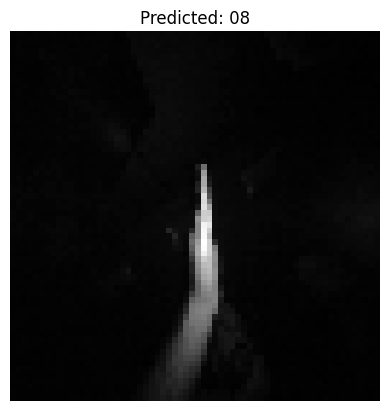

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load model
#model = load_model("gesture_classifier.h5")

# Upload an image to test
uploaded = files.upload()
for fn in uploaded.keys():
    img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # (1, 64, 64, 1)

    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    #class_names = train_dataset.class_names

    print(f"Predicted Class: {class_names[predicted_class]}")

    # Optional: display image
    plt.imshow(img[0].reshape(64, 64), cmap="gray")
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.axis("off")
    plt.show()


In [ ]:
model = load_model("gesture_classifier.h5")

In [ ]:
# Define class labels
class_labels = {
    0: 'Fist',
    1: 'Five',
    2: 'Point',
    3: 'Swing',
    4: 'Ok',
    5: 'Peace',
    6: 'Rock',
    7: 'Thumb'
}

In [ ]:

import cv2
import numpy as np
from google.colab import files
from IPython.display import Image, display

# Function to upload and predict
def upload_and_predict():
    try:
        # Upload file and get file path
        uploaded = files.upload()
        file_path = list(uploaded.keys())[0]  # Assuming only one file is uploaded

        # Load uploaded image or video frame
        img = cv2.imread(file_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB (if needed)
        img = cv2.resize(img, (64, 64))  # Resize image to model's input shape
        img = img.astype('float32') / 255.0  # Normalize pixel values
        img = np.expand_dims(img, axis=0)  # Add batch dimension

        # Predict gesture
        predictions = model.predict(img)
        class_index = np.argmax(predictions)
        class_label = class_labels[class_index]

        # Display uploaded image and prediction
        display(Image(file_path))
        print("Predicted Gesture:", class_label)

    except Exception as e:
        print(f"Error: {str(e)}")

In [ ]:

# Run the function
upload_and_predict()

Saving frame_07_07_0182.png to frame_07_07_0182 (1).png
Error: Exception encountered when calling Sequential.call().

Input 0 of layer "conv2d_15" is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (1, 64, 64, 3)

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 64, 64, 3), dtype=float32)
  • training=False
  • mask=None


In [ ]:
import os
from collections import Counter

# Count images per class
class_counts = Counter()
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    if os.path.isdir(class_path):
        class_counts[class_folder] = len(os.listdir(class_path))

print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class distribution:
09: 10
08: 10
06: 10
07: 10
00: 10
04: 10
02: 10
05: 10
03: 10
01: 10


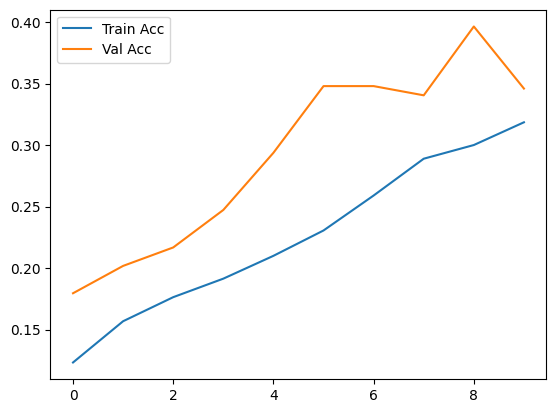

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()
